# Declare Class Augmentation 

In [ ]:
# === IMPORTS ===
try: 
    import os
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    import albumentations as A
    print("📦 Libraries loaded!")
except ImportError as e:
    print(f"❌ Error importing libraries: {e}")
    print("Please install the required libraries using requirement.txt")
    raise

✅ Albumentations available
📦 Libraries loaded!


In [9]:
# === CONFIGURATION ===

DATA_FOLDER               = os.path.join("..", "data")
RAW_FOLDER                = os.path.join(DATA_FOLDER, "raw")
AUGMENTED_FOLDER          = os.path.join(DATA_FOLDER, "augmented")
FINAL_PROCESSED_FOLDER    = os.path.join(DATA_FOLDER, "final_processed")
PREVIEW_FOLDER            = os.path.join(DATA_FOLDER, "preview")
PREVIEW_AUGMENTATION_FOLDER = os.path.join(PREVIEW_FOLDER, "augmentation_samples")
PREVIEW_EVALUATION_FOLDER = os.path.join(PREVIEW_FOLDER, "evaluation_results")

IMAGE_QUALITY = 95   # JPG save quality

# Augmentation settings
AUGMENTATION_TARGET_PER_PERSON = 100   # Target total images per person after augmentation
AUGMENTATION_BRIGHTNESS_LIMIT  = 0.3  # ±30% brightness variation
AUGMENTATION_CONTRAST_LIMIT    = 0.3  # ±30% contrast variation
AUGMENTATION_ROTATION_LIMIT    = 15   # Max rotation angle in degrees
AUGMENTATION_NOISE_VAR_LIMIT   = 25.0 # Gaussian noise variance limit
AUGMENTATION_GAMMA_RANGE       = (0.5, 1.5)  # Gamma correction range

# Create output folders
for folder in [AUGMENTED_FOLDER, PREVIEW_AUGMENTATION_FOLDER, PREVIEW_EVALUATION_FOLDER]:
    os.makedirs(folder, exist_ok=True)

print("⚙️  Configuration loaded!")
print(f"   RAW_FOLDER:              {RAW_FOLDER}")
print(f"   FINAL_PROCESSED_FOLDER:  {FINAL_PROCESSED_FOLDER}")
print(f"   AUGMENTED_FOLDER:        {AUGMENTED_FOLDER}")
print(f"   Target per person:       {AUGMENTATION_TARGET_PER_PERSON}")

⚙️  Configuration loaded!
   RAW_FOLDER:              ..\data\raw
   FINAL_PROCESSED_FOLDER:  ..\data\final_processed
   AUGMENTED_FOLDER:        ..\data\augmented
   Target per person:       100


In [ ]:
class DataAugmentor:
    """Data augmentation pipeline using Albumentations for face recognition training."""
    
    def __init__(self, target_per_person=AUGMENTATION_TARGET_PER_PERSON):
        self.target_per_person = target_per_person
        self.ready = True

        # === BGR/color pipelines (for raw images) ===

        # 1. Illumination variations (most important for attendance system)
        self.illumination_aug = A.Compose([
            A.OneOf([
                A.RandomBrightnessContrast(
                    brightness_limit=AUGMENTATION_BRIGHTNESS_LIMIT,
                    contrast_limit=AUGMENTATION_CONTRAST_LIMIT,
                    p=1.0
                ),
                A.RandomGamma(
                    gamma_limit=(int(AUGMENTATION_GAMMA_RANGE[0] * 100), int(AUGMENTATION_GAMMA_RANGE[1] * 100)),
                    p=1.0
                ),
                A.CLAHE(clip_limit=4.0, tile_grid_size=(4, 4), p=1.0),
            ], p=1.0),
        ])

        # 2. Noise & blur variations
        self.noise_aug = A.Compose([
            A.OneOf([
                A.GaussNoise(var_limit=(10.0, AUGMENTATION_NOISE_VAR_LIMIT), p=1.0),
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                A.ISONoise(color_shift=(0.01, 0.03), intensity=(0.1, 0.3), p=1.0),
            ], p=1.0),
        ])

        # 3. Geometric transforms (subtle - face recognition is pose-sensitive)
        self.geometric_aug = A.Compose([
            A.OneOf([
                A.Rotate(limit=AUGMENTATION_ROTATION_LIMIT, border_mode=cv2.BORDER_REFLECT_101, p=1.0),
                A.HorizontalFlip(p=1.0),
                A.Affine(scale=(0.95, 1.05), translate_percent=(-0.03, 0.03), p=1.0),
            ], p=1.0),
        ])

        # 4. Combined heavy augmentation (mix multiple effects)
        self.combined_aug = A.Compose([
            A.RandomBrightnessContrast(
                brightness_limit=AUGMENTATION_BRIGHTNESS_LIMIT,
                contrast_limit=AUGMENTATION_CONTRAST_LIMIT,
                p=0.7
            ),
            A.OneOf([
                A.GaussNoise(var_limit=(10.0, AUGMENTATION_NOISE_VAR_LIMIT), p=1.0),
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            ], p=0.5),
            A.OneOf([
                A.Rotate(limit=AUGMENTATION_ROTATION_LIMIT, border_mode=cv2.BORDER_REFLECT_101, p=1.0),
                A.HorizontalFlip(p=1.0),
            ], p=0.5),
            A.RandomGamma(
                gamma_limit=(int(AUGMENTATION_GAMMA_RANGE[0] * 100), int(AUGMENTATION_GAMMA_RANGE[1] * 100)),
                p=0.3
            ),
        ])

        self.pipelines = {
            "illumination": self.illumination_aug,
            "noise":        self.noise_aug,
            "geometric":    self.geometric_aug,
            "combined":     self.combined_aug,
        }

        # === Grayscale-safe pipelines (for face crops from final_processed/) ===
        # ISONoise color_shift is excluded — incompatible with single-channel images
        self.grayscale_pipelines = {
            "illumination": A.Compose([
                A.OneOf([
                    A.RandomBrightnessContrast(
                        brightness_limit=AUGMENTATION_BRIGHTNESS_LIMIT,
                        contrast_limit=AUGMENTATION_CONTRAST_LIMIT, p=1.0),
                    A.RandomGamma(
                        gamma_limit=(int(AUGMENTATION_GAMMA_RANGE[0]*100),
                                     int(AUGMENTATION_GAMMA_RANGE[1]*100)), p=1.0),
                    A.CLAHE(clip_limit=4.0, tile_grid_size=(4, 4), p=1.0),
                ], p=1.0),
            ]),
            "noise": A.Compose([
                A.OneOf([
                    A.GaussNoise(var_limit=(10.0, AUGMENTATION_NOISE_VAR_LIMIT), p=1.0),
                    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                ], p=1.0),
            ]),
            "geometric": A.Compose([
                A.OneOf([
                    A.Rotate(limit=AUGMENTATION_ROTATION_LIMIT,
                             border_mode=cv2.BORDER_REFLECT_101, p=1.0),
                    A.HorizontalFlip(p=1.0),
                    A.Affine(scale=(0.95, 1.05), translate_percent=(-0.03, 0.03), p=1.0),
                ], p=1.0),
            ]),
            "combined": A.Compose([
                A.RandomBrightnessContrast(
                    brightness_limit=AUGMENTATION_BRIGHTNESS_LIMIT,
                    contrast_limit=AUGMENTATION_CONTRAST_LIMIT, p=0.7),
                A.OneOf([
                    A.GaussNoise(var_limit=(10.0, AUGMENTATION_NOISE_VAR_LIMIT), p=1.0),
                    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                ], p=0.5),
                A.OneOf([
                    A.Rotate(limit=AUGMENTATION_ROTATION_LIMIT,
                             border_mode=cv2.BORDER_REFLECT_101, p=1.0),
                    A.HorizontalFlip(p=1.0),
                ], p=0.5),
                A.RandomGamma(
                    gamma_limit=(int(AUGMENTATION_GAMMA_RANGE[0]*100),
                                 int(AUGMENTATION_GAMMA_RANGE[1]*100)), p=0.3),
            ]),
        }

        print("✅ DataAugmentor initialized")
        print(f"   • Target per person: {self.target_per_person}")
        print(f"   • Pipelines: {', '.join(self.pipelines.keys())}")
        print(f"   • Brightness range: ±{AUGMENTATION_BRIGHTNESS_LIMIT*100:.0f}%")
        print(f"   • Rotation limit: ±{AUGMENTATION_ROTATION_LIMIT}°")
        print(f"   • Gamma range: {AUGMENTATION_GAMMA_RANGE}")

    def augment_single_image(self, image, pipeline_name="combined"):
        """Apply a single augmentation to one image."""
        pipeline = self.pipelines.get(pipeline_name, self.combined_aug)
        augmented = pipeline(image=image)
        return augmented["image"]

    def augment_person_folder(self, person_name, input_folder, output_folder):
        """
        Augment all images for one person to reach the target count.
        Distributes augmentations evenly across pipeline types.
        Images are pre-loaded into memory to avoid repeated disk reads.
        """
        person_input = os.path.join(input_folder, person_name)

        # Collect original image filenames
        image_extensions = {'.jpg', '.jpeg', '.png'}
        image_files = [f for f in os.listdir(person_input)
                      if Path(f).suffix.lower() in image_extensions]

        if not image_files:
            print(f"  ⚠️ No images found for {person_name} — skipped")
            return 0, 0

        # Pre-load all images into memory (avoids repeated disk reads in the loop)
        loaded_images = {}
        for img_file in image_files:
            img = cv2.imread(os.path.join(person_input, img_file))
            if img is not None:
                loaded_images[img_file] = img
        valid_files = list(loaded_images.keys())

        if not valid_files:
            print(f"  ⚠️ Could not read any images for {person_name} — skipped")
            return 0, 0

        original_count = len(valid_files)
        augmentations_needed = max(0, self.target_per_person - original_count)

        if augmentations_needed == 0:
            print(f"  ✅ {person_name}: already has {original_count} images (target: {self.target_per_person})")
            return original_count, 0

        person_output = os.path.join(output_folder, person_name)
        os.makedirs(person_output, exist_ok=True)

        # Step 1: Copy originals to output folder
        for img_file, image in loaded_images.items():
            cv2.imwrite(os.path.join(person_output, img_file), image,
                        [cv2.IMWRITE_JPEG_QUALITY, IMAGE_QUALITY])

        # Step 2: Generate augmented images (images already in memory — no disk re-reads)
        pipeline_names = list(self.pipelines.keys())
        augmented_count = 0
        aug_index = 0

        while augmented_count < augmentations_needed:
            for img_file in valid_files:
                if augmented_count >= augmentations_needed:
                    break

                image = loaded_images[img_file]  # from memory
                pipeline_name = pipeline_names[aug_index % len(pipeline_names)]

                try:
                    aug_image = self.augment_single_image(image, pipeline_name)
                    base_name = Path(img_file).stem
                    aug_filename = f"{base_name}_aug_{pipeline_name}_{aug_index:03d}.jpg"
                    cv2.imwrite(os.path.join(person_output, aug_filename), aug_image,
                                [cv2.IMWRITE_JPEG_QUALITY, IMAGE_QUALITY])
                    augmented_count += 1
                    aug_index += 1
                except Exception as e:
                    print(f"  ⚠️ Augmentation failed for {img_file} ({pipeline_name}): {e}")
                    aug_index += 1

        total = original_count + augmented_count
        print(f"  ✅ {person_name}: {original_count} originals + {augmented_count} augmented = {total} total")
        return original_count, augmented_count

    def augment_all(self, input_folder, output_folder):
        """Augment images for all people in the dataset."""
        print("🔄 STARTING DATA AUGMENTATION")
        print("=" * 55)
        print(f"📁 Input:  {input_folder}")
        print(f"📁 Output: {output_folder}")
        print(f"🎯 Target: {self.target_per_person} images per person\n")

        os.makedirs(output_folder, exist_ok=True)

        person_names = sorted([
            f for f in os.listdir(input_folder)
            if os.path.isdir(os.path.join(input_folder, f))
        ])

        if not person_names:
            print("❌ No person folders found!")
            return {}

        results = {}
        total_originals = 0
        total_augmented = 0

        for person in person_names:
            originals, augmented = self.augment_person_folder(person, input_folder, output_folder)
            if originals == 0:
                continue
            results[person] = {"originals": originals, "augmented": augmented, "total": originals + augmented}
            total_originals += originals
            total_augmented += augmented

        print(f"\n{'=' * 55}")
        print(f"✨ AUGMENTATION COMPLETE!")
        print(f"  👥 People processed: {len(results)}")
        print(f"  📷 Original images:  {total_originals}")
        print(f"  🔄 Augmented images: {total_augmented}")
        print(f"  📊 Total dataset:    {total_originals + total_augmented}")
        if total_originals > 0:
            print(f"  📈 Multiplication:   {(total_originals + total_augmented) / total_originals:.1f}x")
        print(f"  📁 Output folder:    {output_folder}")

        return results

# Initialize augmentor
augmentor = DataAugmentor()
print("\n🔄 Data augmentor ready!")


✅ DataAugmentor initialized
   • Target per person: 100
   • Pipelines: illumination, noise, geometric, combined
   • Brightness range: ±30%
   • Rotation limit: ±15°
   • Gamma range: (0.5, 1.5)

🔄 Data augmentor ready!


C:\Users\jaft9\AppData\Local\Temp\ipykernel_31228\1618610437.py:35: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, AUGMENTATION_NOISE_VAR_LIMIT), p=1.0),
C:\Users\jaft9\AppData\Local\Temp\ipykernel_31228\1618610437.py:58: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, AUGMENTATION_NOISE_VAR_LIMIT), p=1.0),


# Run Augmentation

In [11]:
def run_augmentation():
    """Run data augmentation on all raw images."""
    print("🔄 RUNNING DATA AUGMENTATION PIPELINE")
    print("=" * 55)
    
    if not os.path.exists(RAW_FOLDER):
        print(f"❌ Raw folder not found: {RAW_FOLDER}")
        print("   Please add person photos to data/raw/[person_name]/ first.")
        return None
    
    # Check if any person folders have images
    person_dirs = [d for d in os.listdir(RAW_FOLDER) 
                   if os.path.isdir(os.path.join(RAW_FOLDER, d))]
    
    non_empty = []
    for d in person_dirs:
        files = [f for f in os.listdir(os.path.join(RAW_FOLDER, d))
                 if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png', '.heic'}]
        if files:
            non_empty.append((d, len(files)))
    
    if not non_empty:
        print(f"⚠️ No images found in any raw/{'{person}'}/ folder.")
        print(f"   Found {len(person_dirs)} person folders but all are empty.")
        return None
    
    print(f"📋 Found {len(non_empty)} people with images:")
    for name, count in non_empty:
        aug_needed = max(0, AUGMENTATION_TARGET_PER_PERSON - count)
        print(f"   👤 {name}: {count} images → +{aug_needed} augmentations needed")
    
    print()
    
    # Run augmentation
    results = augmentor.augment_all(RAW_FOLDER, AUGMENTED_FOLDER)
    
    return results

# Run augmentation
augmentation_results = run_augmentation()

🔄 RUNNING DATA AUGMENTATION PIPELINE
📋 Found 18 people with images:
   👤 benjamin: 41 images → +59 augmentations needed
   👤 chern_tak: 36 images → +64 augmentations needed
   👤 chillien: 6 images → +94 augmentations needed
   👤 daniel: 54 images → +46 augmentations needed
   👤 Dr.Nurul: 11 images → +89 augmentations needed
   👤 dylan: 40 images → +60 augmentations needed
   👤 han_soon: 11 images → +89 augmentations needed
   👤 harry: 23 images → +77 augmentations needed
   👤 kang_kai: 6 images → +94 augmentations needed
   👤 marion: 2 images → +98 augmentations needed
   👤 qi_xuan: 2 images → +98 augmentations needed
   👤 shuang_quan: 56 images → +44 augmentations needed
   👤 wee_xuan: 16 images → +84 augmentations needed
   👤 xiang_yue: 24 images → +76 augmentations needed
   👤 xu_sheng: 23 images → +77 augmentations needed
   👤 yoke_hong: 49 images → +51 augmentations needed
   👤 yong_kang: 3 images → +97 augmentations needed
   👤 zi_herng: 1 images → +99 augmentations needed

🔄 STA

# Augment Face Crops for Training

In [ ]:
def augment_face_crops(input_folder=None, output_folder=None,
                       target_per_person=AUGMENTATION_TARGET_PER_PERSON):
    """
    Augment extracted face crops for LBPH training.
    Reads 128×128 grayscale face crops and applies grayscale-safe augmentation.
    Reuses augmentor.grayscale_pipelines — no duplicate pipeline definitions.
    Images are pre-loaded into memory to avoid repeated disk reads.

    Args:
        input_folder: Source folder with face crops (default: FINAL_PROCESSED_FOLDER)
        output_folder: Destination folder (default: AUGMENTED_FOLDER)
        target_per_person: Target total images per person after augmentation
    """
    if input_folder is None:
        input_folder = FINAL_PROCESSED_FOLDER
    if output_folder is None:
        output_folder = AUGMENTED_FOLDER

    if not os.path.exists(input_folder):
        print(f"❌ Source folder not found: {input_folder}")
        print("   Run the face extraction pipeline (Steps 1-4) first.")
        return None

    print("🔄 AUGMENTING FACE CROPS FOR TRAINING")
    print("=" * 55)
    print(f"📁 Input:  {input_folder}")
    print(f"📁 Output: {output_folder}")
    print(f"🎯 Target: {target_per_person} images per person\n")

    # Reuse grayscale-safe pipelines from augmentor (no code duplication)
    pipelines = augmentor.grayscale_pipelines
    pipeline_names = list(pipelines.keys())

    person_names = sorted([
        f for f in os.listdir(input_folder)
        if os.path.isdir(os.path.join(input_folder, f))
    ])

    if not person_names:
        print("❌ No person folders found in source!")
        return None

    results = {}
    total_originals = 0
    total_augmented = 0

    for person in person_names:
        person_input = os.path.join(input_folder, person)

        # Collect face crop filenames
        image_files = sorted([
            f for f in os.listdir(person_input)
            if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}
        ])

        if not image_files:
            print(f"  ⚠️ No face crops found for {person} — skipped")
            continue

        person_output = os.path.join(output_folder, person)
        os.makedirs(person_output, exist_ok=True)

        # Pre-load all face crops into memory (avoids repeated disk reads in the loop)
        loaded = {}
        for img_file in image_files:
            img = cv2.imread(os.path.join(person_input, img_file), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                loaded[img_file] = img
        valid_files = list(loaded.keys())

        original_count = len(valid_files)
        augmentations_needed = max(0, target_per_person - original_count)

        # Step 1: Copy originals to output
        for img_file, img in loaded.items():
            cv2.imwrite(os.path.join(person_output, img_file), img,
                        [cv2.IMWRITE_JPEG_QUALITY, IMAGE_QUALITY])

        # Step 2: Generate augmented face crops (images already in memory)
        aug_count = 0
        aug_idx = 0

        while aug_count < augmentations_needed:
            for img_file in valid_files:
                if aug_count >= augmentations_needed:
                    break

                img = loaded[img_file]  # from memory — no disk read
                # Albumentations needs 3-channel input; convert back to gray after
                img_3ch = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

                pipeline_name = pipeline_names[aug_idx % len(pipeline_names)]
                pipeline = pipelines[pipeline_name]

                try:
                    augmented = pipeline(image=img_3ch)["image"]
                    aug_gray = cv2.cvtColor(augmented, cv2.COLOR_BGR2GRAY)

                    base_name = Path(img_file).stem
                    aug_filename = f"{base_name}_faug_{pipeline_name}_{aug_idx:03d}.jpg"
                    cv2.imwrite(os.path.join(person_output, aug_filename), aug_gray,
                                [cv2.IMWRITE_JPEG_QUALITY, IMAGE_QUALITY])
                    aug_count += 1
                    aug_idx += 1
                except Exception as e:
                    print(f"  ⚠️ Augmentation failed: {img_file} ({pipeline_name}): {e}")
                    aug_idx += 1

        total = original_count + aug_count
        total_originals += original_count
        total_augmented += aug_count
        results[person] = {"originals": original_count, "augmented": aug_count, "total": total}
        print(f"  ✅ {person}: {original_count} originals + {aug_count} augmented = {total} total")

    print(f"\n{'=' * 55}")
    print(f"✨ FACE CROP AUGMENTATION COMPLETE!")
    print(f"  👥 People: {len(person_names)}")
    print(f"  📷 Original face crops: {total_originals}")
    print(f"  🔄 Augmented crops:     {total_augmented}")
    print(f"  📊 Total training data: {total_originals + total_augmented}")
    if total_originals > 0:
        print(f"  📈 Multiplication:      {(total_originals + total_augmented) / total_originals:.1f}x")
    print(f"  📁 Output: {output_folder}")

    return results

# Run face crop augmentation (augments final_processed/ → augmented/)
face_crop_aug_results = augment_face_crops()


🔄 AUGMENTING FACE CROPS FOR TRAINING
📁 Input:  ..\data\final_processed
📁 Output: ..\data\augmented
🎯 Target: 100 images per person

  ✅ Dr.Nurul: 18 originals + 82 augmented = 100 total
  ✅ benjamin: 12 originals + 88 augmented = 100 total


C:\Users\jaft9\AppData\Local\Temp\ipykernel_31228\1570606923.py:49: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, AUGMENTATION_NOISE_VAR_LIMIT), p=1.0),
C:\Users\jaft9\AppData\Local\Temp\ipykernel_31228\1570606923.py:68: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, AUGMENTATION_NOISE_VAR_LIMIT), p=1.0),


  ✅ chern_tak: 26 originals + 74 augmented = 100 total
  ✅ chillien: 8 originals + 92 augmented = 100 total
  ✅ daniel: 42 originals + 58 augmented = 100 total
  ✅ dylan: 7 originals + 93 augmented = 100 total
  ✅ han_soon: 10 originals + 90 augmented = 100 total
  ✅ harry: 15 originals + 85 augmented = 100 total
  ✅ kang_kai: 11 originals + 89 augmented = 100 total
  ⚠️ No face crops found for marion
  ✅ qi_xuan: 4 originals + 96 augmented = 100 total
  ✅ shuang_quan: 12 originals + 88 augmented = 100 total
  ✅ wee_xuan: 23 originals + 77 augmented = 100 total
  ✅ xiang_yue: 2 originals + 98 augmented = 100 total
  ✅ xu_sheng: 2 originals + 98 augmented = 100 total
  ✅ yoke_hong: 26 originals + 74 augmented = 100 total
  ✅ yong_kang: 8 originals + 92 augmented = 100 total
  ✅ zi_herng: 2 originals + 98 augmented = 100 total

✨ FACE CROP AUGMENTATION COMPLETE!
  👥 People: 18
  📷 Original face crops: 228
  🔄 Augmented crops:     1472
  📊 Total training data: 1700
  📈 Multiplication:    

# Augmentation Preview

👁️ AUGMENTATION PREVIEW - benjamin
   Showing 2 original(s) × 4 pipelines

  💾 Saved preview: ..\data\preview\augmentation_samples\aug_preview_benjamin_IMG_1924.jpg


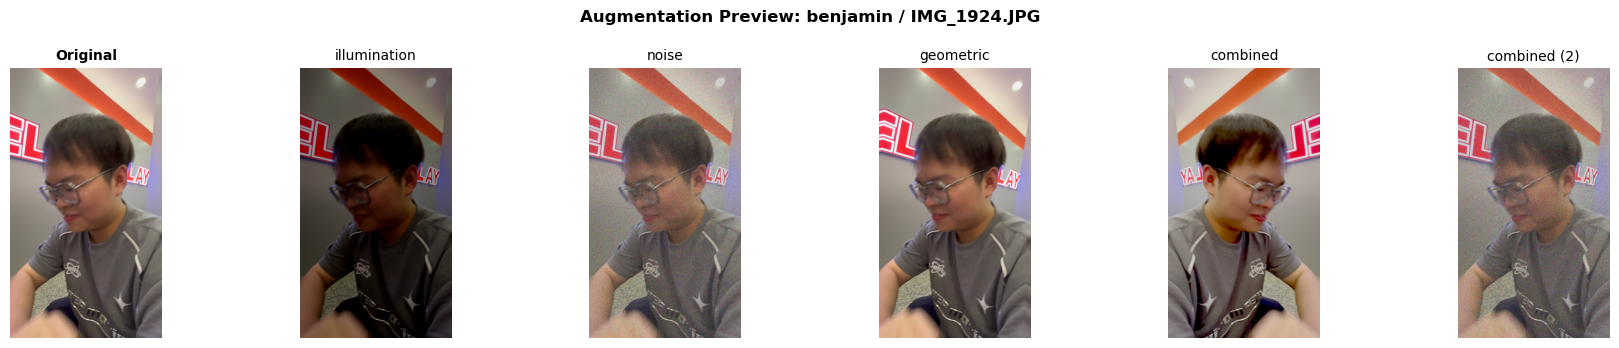

  💾 Saved preview: ..\data\preview\augmentation_samples\aug_preview_benjamin_IMG_1925.jpg


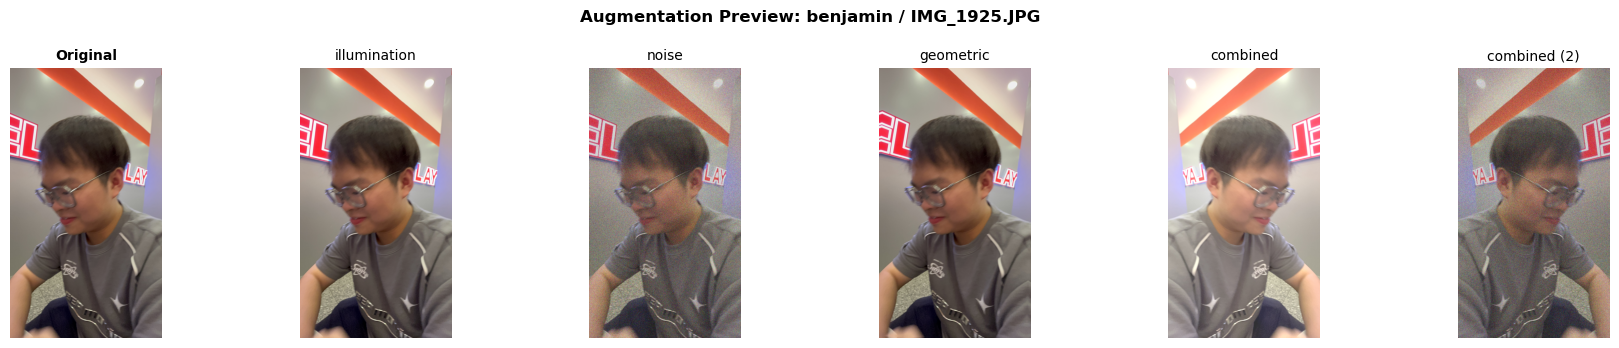


✅ Preview complete for benjamin


In [13]:
def preview_augmentation_samples(person_name=None, num_samples=1, save_preview=True):
    """
    Generate and display augmentation previews for each pipeline type.
    
    Args:
        person_name: Specific person to preview (None = pick first available)
        num_samples: Number of original images to show augmentation for
        save_preview: Whether to save preview images to preview/ folder
    """
    if not augmentor.ready:
        print("❌ Augmentor not ready.")
        return
    
    # Find a person with images
    if person_name is None:
        for d in sorted(os.listdir(RAW_FOLDER)):
            person_path = os.path.join(RAW_FOLDER, d)
            if os.path.isdir(person_path):
                imgs = [f for f in os.listdir(person_path) 
                       if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}]
                if imgs:
                    person_name = d
                    break
    
    if person_name is None:
        print("❌ No person with images found in raw/ folder.")
        return
    
    person_path = os.path.join(RAW_FOLDER, person_name)
    image_files = sorted([f for f in os.listdir(person_path) 
                         if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}])
    
    if not image_files:
        print(f"❌ No images found for {person_name}")
        return
    
    # Pick sample images
    sample_files = image_files[:num_samples]
    pipeline_names = list(augmentor.pipelines.keys())
    
    print(f"👁️ AUGMENTATION PREVIEW - {person_name}")
    print(f"=" * 50)
    print(f"   Showing {len(sample_files)} original(s) × {len(pipeline_names)} pipelines\n")
    
    for img_file in sample_files:
        img_path = os.path.join(person_path, img_file)
        original = cv2.imread(img_path)
        
        if original is None:
            print(f"  ❌ Failed to read: {img_file}")
            continue
        
        original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        
        # Generate one augmentation per pipeline + 1 extra combined
        num_cols = 1 + len(pipeline_names) + 1  # original + each pipeline + extra combined
        fig, axes = plt.subplots(1, num_cols, figsize=(3 * num_cols, 3.5))
        
        # Show original
        axes[0].imshow(original_rgb)
        axes[0].set_title("Original", fontsize=10, fontweight='bold')
        axes[0].axis('off')
        
        # Show each pipeline
        for i, pname in enumerate(pipeline_names):
            aug_img = augmentor.augment_single_image(original, pname)
            aug_rgb = cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB)
            axes[i + 1].imshow(aug_rgb)
            axes[i + 1].set_title(f"{pname}", fontsize=10)
            axes[i + 1].axis('off')
        
        # Extra combined variant
        aug_extra = augmentor.augment_single_image(original, "combined")
        aug_extra_rgb = cv2.cvtColor(aug_extra, cv2.COLOR_BGR2RGB)
        axes[-1].imshow(aug_extra_rgb)
        axes[-1].set_title("combined (2)", fontsize=10)
        axes[-1].axis('off')
        
        plt.suptitle(f"Augmentation Preview: {person_name} / {img_file}", fontsize=12, fontweight='bold')
        plt.tight_layout()
        
        # Save preview
        if save_preview:
            os.makedirs(PREVIEW_AUGMENTATION_FOLDER, exist_ok=True)
            preview_path = os.path.join(PREVIEW_AUGMENTATION_FOLDER, 
                                        f"aug_preview_{person_name}_{Path(img_file).stem}.jpg")
            fig.savefig(preview_path, dpi=150, bbox_inches='tight')
            print(f"  💾 Saved preview: {preview_path}")
        
        plt.show()
    
    print(f"\n✅ Preview complete for {person_name}")

# Preview augmentation samples (change person_name to preview a specific person)
preview_augmentation_samples(person_name=None, num_samples=2, save_preview=True)

## Illumination Robustness Evaluation

📊 ILLUMINATION ROBUSTNESS EVALUATION

🔍 Analyzing raw images...
🔍 Analyzing augmented images...

💾 Evaluation saved: ..\data\preview\evaluation_results\illumination_robustness_evaluation.png


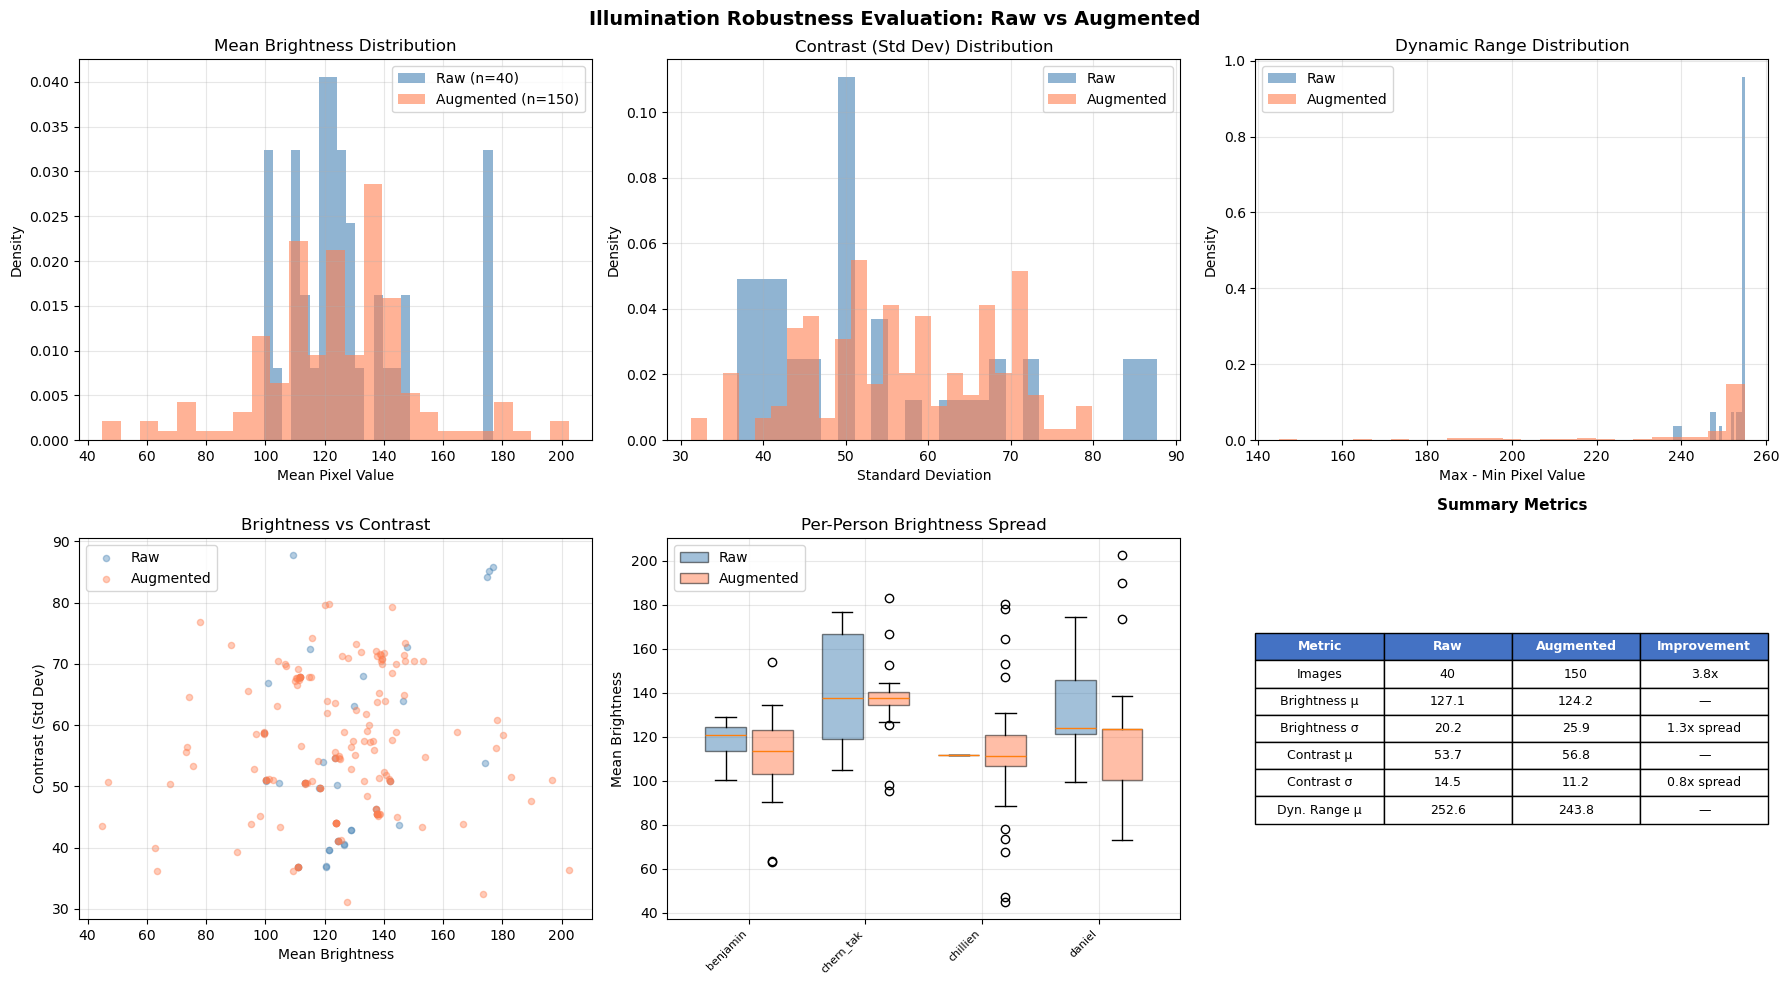


📊 EVALUATION SUMMARY
───────────────────────────────────────────────────────
  Raw dataset:       40 images
  Augmented dataset: 150 images
  Brightness spread: 20.2 → 25.9 (1.3x wider)
  Contrast spread:   14.5 → 11.2 (0.8x wider)

  ⚠️ Moderate improvement. Consider increasing brightness/gamma augmentation ranges.


In [14]:
def evaluate_illumination_robustness(source_folder=None, max_persons=5, max_images_per_person=30):
    """
    Evaluate illumination diversity across original vs augmented datasets.
    Generates metrics: mean brightness, contrast (std), histogram spread,
    and visual comparisons saved to preview/evaluation_results/.
    
    Args:
        source_folder: Folder to evaluate (default: AUGMENTED_FOLDER)
        max_persons: Max people to sample for evaluation
        max_images_per_person: Max images per person to sample
    """
    if source_folder is None:
        source_folder = AUGMENTED_FOLDER
    
    print("📊 ILLUMINATION ROBUSTNESS EVALUATION")
    print("=" * 55)
    
    if not os.path.exists(source_folder):
        print(f"❌ Folder not found: {source_folder}")
        print("   Run augmentation first.")
        return
    
    if not os.path.exists(RAW_FOLDER):
        print(f"❌ Raw folder not found: {RAW_FOLDER}")
        return
    
    os.makedirs(PREVIEW_EVALUATION_FOLDER, exist_ok=True)
    
    def compute_image_stats(folder, max_persons, max_per_person):
        """Compute brightness & contrast stats for images in a folder."""
        stats_list = []
        person_dirs = sorted([d for d in os.listdir(folder) 
                             if os.path.isdir(os.path.join(folder, d))])[:max_persons]
        
        for person in person_dirs:
            person_path = os.path.join(folder, person)
            img_files = sorted([f for f in os.listdir(person_path) 
                               if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}])[:max_per_person]
            
            for img_file in img_files:
                img = cv2.imread(os.path.join(person_path, img_file), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    stats_list.append({
                        "person": person,
                        "file": img_file,
                        "mean_brightness": float(np.mean(img)),
                        "std_contrast": float(np.std(img)),
                        "min_pixel": int(np.min(img)),
                        "max_pixel": int(np.max(img)),
                        "dynamic_range": int(np.max(img)) - int(np.min(img)),
                    })
        return stats_list
    
    # Compute stats for raw and augmented datasets
    print("\n🔍 Analyzing raw images...")
    raw_stats = compute_image_stats(RAW_FOLDER, max_persons, max_images_per_person)
    
    print(f"🔍 Analyzing augmented images...")
    aug_stats = compute_image_stats(source_folder, max_persons, max_images_per_person)
    
    if not raw_stats or not aug_stats:
        print("❌ Not enough data to evaluate. Ensure both raw and augmented folders have images.")
        return
    
    # Extract arrays for plotting
    raw_brightness = [s["mean_brightness"] for s in raw_stats]
    raw_contrast   = [s["std_contrast"] for s in raw_stats]
    raw_range      = [s["dynamic_range"] for s in raw_stats]
    
    aug_brightness = [s["mean_brightness"] for s in aug_stats]
    aug_contrast   = [s["std_contrast"] for s in aug_stats]
    aug_range      = [s["dynamic_range"] for s in aug_stats]
    
    # === VISUALIZATION ===
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Illumination Robustness Evaluation: Raw vs Augmented", fontsize=14, fontweight='bold')
    
    # 1. Brightness distribution
    axes[0, 0].hist(raw_brightness, bins=25, alpha=0.6, color='steelblue', label=f'Raw (n={len(raw_stats)})', density=True)
    axes[0, 0].hist(aug_brightness, bins=25, alpha=0.6, color='coral', label=f'Augmented (n={len(aug_stats)})', density=True)
    axes[0, 0].set_title("Mean Brightness Distribution")
    axes[0, 0].set_xlabel("Mean Pixel Value")
    axes[0, 0].set_ylabel("Density")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Contrast distribution
    axes[0, 1].hist(raw_contrast, bins=25, alpha=0.6, color='steelblue', label='Raw', density=True)
    axes[0, 1].hist(aug_contrast, bins=25, alpha=0.6, color='coral', label='Augmented', density=True)
    axes[0, 1].set_title("Contrast (Std Dev) Distribution")
    axes[0, 1].set_xlabel("Standard Deviation")
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Dynamic range distribution
    axes[0, 2].hist(raw_range, bins=25, alpha=0.6, color='steelblue', label='Raw', density=True)
    axes[0, 2].hist(aug_range, bins=25, alpha=0.6, color='coral', label='Augmented', density=True)
    axes[0, 2].set_title("Dynamic Range Distribution")
    axes[0, 2].set_xlabel("Max - Min Pixel Value")
    axes[0, 2].set_ylabel("Density")
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Brightness vs Contrast scatter
    axes[1, 0].scatter(raw_brightness, raw_contrast, alpha=0.4, c='steelblue', label='Raw', s=20)
    axes[1, 0].scatter(aug_brightness, aug_contrast, alpha=0.4, c='coral', label='Augmented', s=20)
    axes[1, 0].set_title("Brightness vs Contrast")
    axes[1, 0].set_xlabel("Mean Brightness")
    axes[1, 0].set_ylabel("Contrast (Std Dev)")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Per-person brightness boxplot
    persons_raw = sorted(set(s["person"] for s in raw_stats))[:max_persons]
    raw_bright_by_person = [[s["mean_brightness"] for s in raw_stats if s["person"] == p] for p in persons_raw]
    aug_bright_by_person = [[s["mean_brightness"] for s in aug_stats if s["person"] == p] for p in persons_raw]
    
    x = np.arange(len(persons_raw))
    bp1 = axes[1, 1].boxplot(raw_bright_by_person, positions=x - 0.2, widths=0.35,
                              patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.5))
    bp2 = axes[1, 1].boxplot(aug_bright_by_person, positions=x + 0.2, widths=0.35,
                              patch_artist=True, boxprops=dict(facecolor='coral', alpha=0.5))
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(persons_raw, rotation=45, ha='right', fontsize=8)
    axes[1, 1].set_title("Per-Person Brightness Spread")
    axes[1, 1].set_ylabel("Mean Brightness")
    axes[1, 1].legend([bp1["boxes"][0], bp2["boxes"][0]], ['Raw', 'Augmented'])
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Summary metrics table
    axes[1, 2].axis('off')
    metrics = [
        ["Metric", "Raw", "Augmented", "Improvement"],
        ["Images", f"{len(raw_stats)}", f"{len(aug_stats)}", f"{len(aug_stats)/max(1,len(raw_stats)):.1f}x"],
        ["Brightness μ", f"{np.mean(raw_brightness):.1f}", f"{np.mean(aug_brightness):.1f}", "—"],
        ["Brightness σ", f"{np.std(raw_brightness):.1f}", f"{np.std(aug_brightness):.1f}", 
         f"{np.std(aug_brightness)/max(0.01, np.std(raw_brightness)):.1f}x spread"],
        ["Contrast μ", f"{np.mean(raw_contrast):.1f}", f"{np.mean(aug_contrast):.1f}", "—"],
        ["Contrast σ", f"{np.std(raw_contrast):.1f}", f"{np.std(aug_contrast):.1f}",
         f"{np.std(aug_contrast)/max(0.01, np.std(raw_contrast)):.1f}x spread"],
        ["Dyn. Range μ", f"{np.mean(raw_range):.1f}", f"{np.mean(aug_range):.1f}", "—"],
    ]
    
    table = axes[1, 2].table(cellText=metrics, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.5)
    
    # Style header row
    for j in range(4):
        table[0, j].set_facecolor('#4472C4')
        table[0, j].set_text_props(color='white', fontweight='bold')
    
    axes[1, 2].set_title("Summary Metrics", fontsize=11, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    # Save evaluation figure
    eval_path = os.path.join(PREVIEW_EVALUATION_FOLDER, "illumination_robustness_evaluation.png")
    fig.savefig(eval_path, dpi=150, bbox_inches='tight')
    print(f"\n💾 Evaluation saved: {eval_path}")
    
    plt.show()
    
    # Print text summary
    print(f"\n📊 EVALUATION SUMMARY")
    print(f"{'─' * 55}")
    print(f"  Raw dataset:       {len(raw_stats)} images")
    print(f"  Augmented dataset: {len(aug_stats)} images")
    print(f"  Brightness spread: {np.std(raw_brightness):.1f} → {np.std(aug_brightness):.1f} "
          f"({np.std(aug_brightness)/max(0.01, np.std(raw_brightness)):.1f}x wider)")
    print(f"  Contrast spread:   {np.std(raw_contrast):.1f} → {np.std(aug_contrast):.1f} "
          f"({np.std(aug_contrast)/max(0.01, np.std(raw_contrast)):.1f}x wider)")
    
    spread_improvement = np.std(aug_brightness) / max(0.01, np.std(raw_brightness))
    if spread_improvement > 1.5:
        print(f"\n  ✅ Good illumination diversity! Augmentation significantly widens the brightness range.")
    elif spread_improvement > 1.1:
        print(f"\n  ⚠️ Moderate improvement. Consider increasing brightness/gamma augmentation ranges.")
    else:
        print(f"\n  ❌ Minimal improvement. The augmentation may not be adding enough lighting variation.")

# Run illumination evaluation
evaluate_illumination_robustness(max_persons=5, max_images_per_person=30)